In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

print("All Libraries loaded successfully")

All Libraries loaded successfully


In [2]:
df=pd.read_csv('../data/train.csv')
print("Rows and Columns:", df.shape)
df.head()

Rows and Columns: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
#To check colummn information
print("Total Columns:", len(df.columns))
print("\nColumns names:")
print(df.columns.tolist())# tolist is used taaki ham saare feature ko list ke form me kr de

Total Columns: 81

Columns names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', '

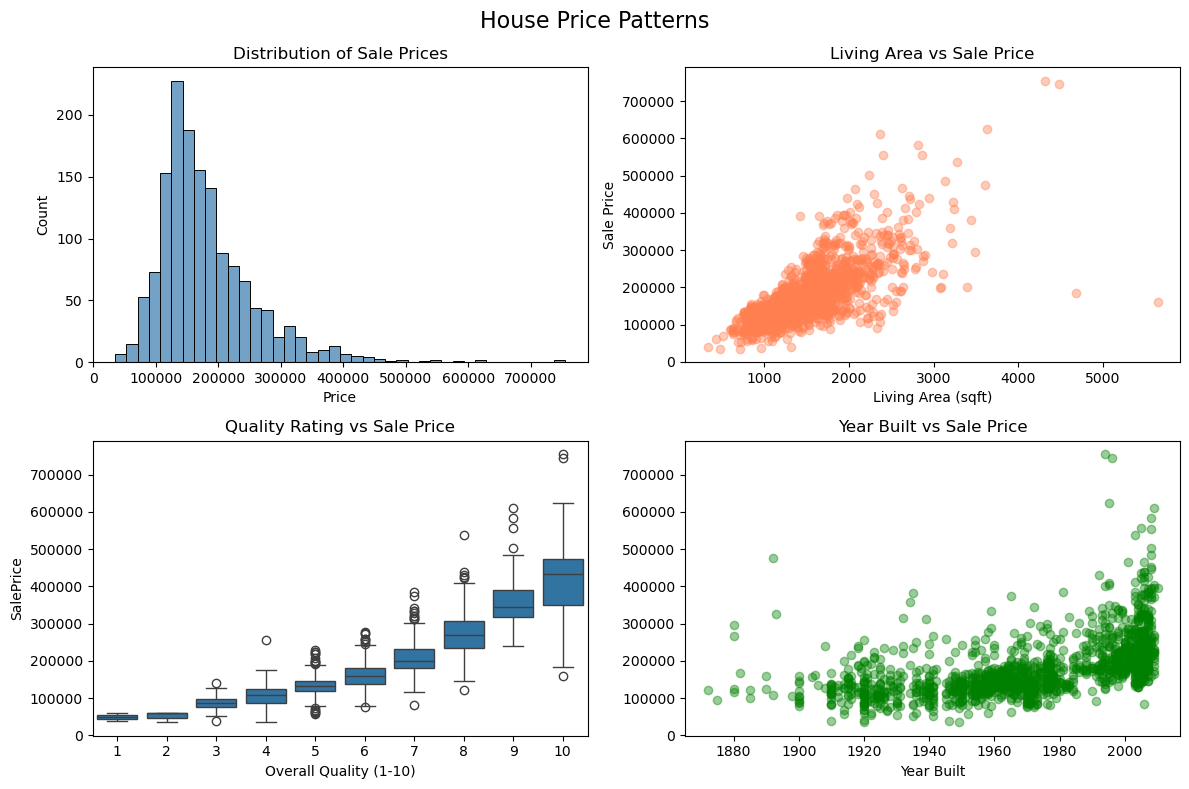

Charts saved!


In [5]:
# visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('House Price Patterns', fontsize=16)

# Chart 1
sns.histplot(df['SalePrice'], ax=axes[0,0], color='steelblue', bins=40)
axes[0,0].set_title('Distribution of Sale Prices')
axes[0,0].set_xlabel('Price')

# Chart 2
axes[0,1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='coral')
axes[0,1].set_title('Living Area vs Sale Price')
axes[0,1].set_xlabel('Living Area (sqft)')
axes[0,1].set_ylabel('Sale Price')

# Chart 3
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[1,0])
axes[1,0].set_title('Quality Rating vs Sale Price')
axes[1,0].set_xlabel('Overall Quality (1-10)')

# Chart 4
axes[1,1].scatter(df['YearBuilt'], df['SalePrice'], alpha=0.4, color='green')
axes[1,1].set_title('Year Built vs Sale Price')
axes[1,1].set_xlabel('Year Built')

plt.tight_layout()
plt.savefig('../output/eda_charts.png')
plt.show()
print("Charts saved!")

In [6]:
# to find the misisng value
missing=df.isnull().sum()
print(missing)

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [7]:
missing=missing[missing>0].sort_values(ascending=False)
print("columns with missing values:\n")
print(missing)

columns with missing values:

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [8]:
print("Sale Price Summary:")
print(df['SalePrice'].describe())

print("\nCheapest house : $", df['SalePrice'].min())
print("Most expensive : $", df['SalePrice'].max())
print("Average price  : $", round(df['SalePrice'].mean(), 2))

Sale Price Summary:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Cheapest house : $ 34900
Most expensive : $ 755000
Average price  : $ 180921.2


In [9]:
# resolve missing value by taking mean foe the numeric value
numeric=df.select_dtypes(include=['int64','float64']).columns
df[numeric]=df[numeric].fillna(
    df[numeric].mean()
    )

In [10]:
# resolving missing text by replacing the Nan into none
text=df.select_dtypes(include=['object']).columns
df[text]=df[text].fillna("None")

In [11]:
print(df.isnull().sum().sum())

0


In [12]:
# removal of outlier(jo exceptional ho rha tha mtlb kam price me jyada ground area)
print("Before:", len(df))

df = df[
    ~(
        (df['GrLivArea'] > 4000) &
        (df['SalePrice'] < 200000)
    )
]

print("After:", len(df))

Before: 1460
After: 1458


In [13]:
# Label Encoding 
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col]=le.fit_transform(df[col])

print("All text columns converted to numbers")

All text columns converted to numbers


In [14]:
X = df.drop('SalePrice', axis=1)
Y = df['SalePrice']

print(X.shape)
print(Y.shape)

(1458, 80)
(1458,)


In [15]:
# train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,  
    random_state=42   
)

print("X_train shape:", X_train.shape)  
print("X_test shape :", X_test.shape)   
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1166, 80)
X_test shape : (292, 80)
y_train shape: (1166,)
y_test shape : (292,)


In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")
print("")
print("X_train_scaled min:", X_train_scaled.min().round(2))
print("X_train_scaled max:", X_train_scaled.max().round(2))
print("")
print("X_test_scaled min :", X_test_scaled.min().round(2))
print("X_test_scaled max :", X_test_scaled.max().round(2))

Scaling done!

X_train_scaled min: 0.0
X_train_scaled max: 1.0

X_test_scaled min : -0.5
X_test_scaled max : 1.31


In [17]:
print("Training features :", X_train_scaled.shape)
print("Training target   :", y_train.shape)
print("Testing features  :", X_test_scaled.shape)
print("Testing target    :", y_test.shape)
print("")
print("Missing in train  :", X_train.isnull().sum().sum())
print("Missing in test   :", X_test.isnull().sum().sum())
print("")
print("You are ready to build the model!")

Training features : (1166, 80)
Training target   : (1166,)
Testing features  : (292, 80)
Testing target    : (292,)

Missing in train  : 0
Missing in test   : 0

You are ready to build the model!


In [18]:
# Linear Regression
#Train the Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print("")
print("Number of features used:", model.n_features_in_)
print("Model intercept        :", round(model.intercept_, 2))

Model trained successfully!

Number of features used: 80
Model intercept        : -6031074746069704.0


In [19]:
# predict the prices
y_pred=model.predict(X_test_scaled)
print("Predicted first 5 prices :",y_pred[:5])
print("Actual first 5 prices:",y_test[:5].values)

Predicted first 5 prices : [233683.  86938. 106049. 175472. 323486.]
Actual first 5 prices: [190000 100000 115000 159000 315500]


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score : {r2:.4f}")
print(f"MAE      : ${mae:,.0f}")
print(f"RMSE     : ${rmse:,.0f}")

R² Score : 0.8786
MAE      : $18,765
RMSE     : $25,894


In [21]:
if r2 >= 0.85:
    print("Excellent model!")
elif r2 >= 0.75:
    print("Good model — can be improved")
elif r2 >= 0.60:
    print("Decent model — needs improvement")
else:
    print("Weak model — try Random Forest next")

Excellent model!


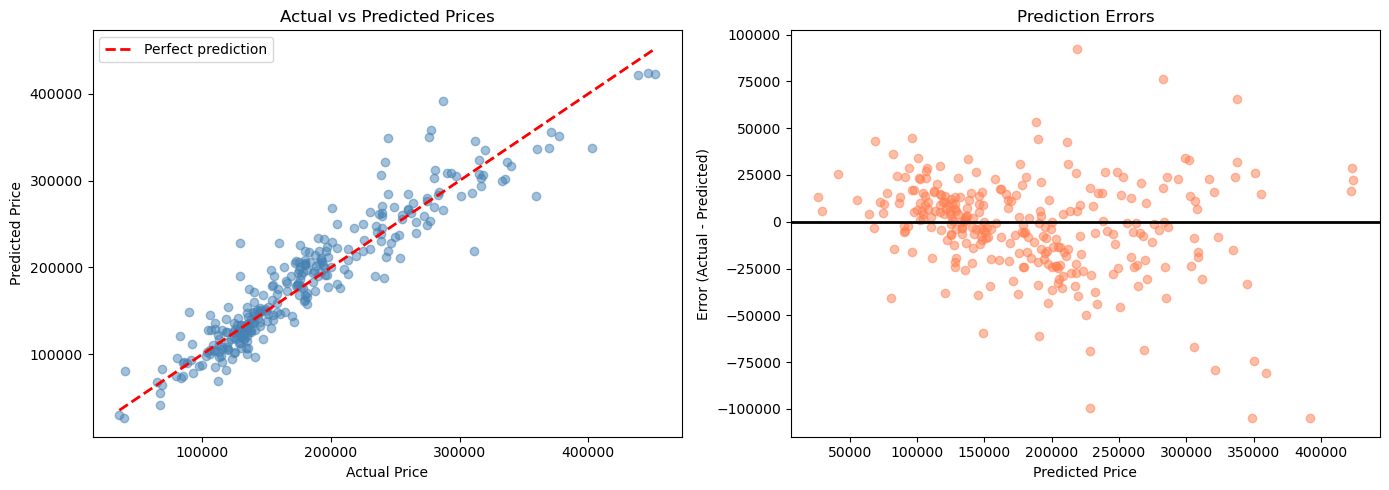

Charts saved!


In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 
axes[0].scatter(y_test, y_pred, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted Prices')
axes[0].legend()

# Chart 2 
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='coral')
axes[1].axhline(y=0, color='black', linewidth=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Error (Actual - Predicted)')
axes[1].set_title('Prediction Errors')

plt.tight_layout()
plt.savefig('../output/model_results.png')
plt.show()
print("Charts saved!")

In [23]:
# random forest algorithm
from sklearn.ensemble import RandomForestRegressor

# Create and train 
rf_model = RandomForestRegressor(
    n_estimators=100,   # 100 decision trees
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

# Predict
rf_pred = rf_model.predict(X_test_scaled)

# Evaluate
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)


In [24]:
print("RANDOM FOREST PERFORMANCE")
print(f"MAE  : ${rf_mae:,.0f}")
print(f"RMSE : ${rf_rmse:,.0f}")
print(f"R²   : {rf_r2:.4f}")
print("")
print("LINEAR REGRESSION PERFORMANCE")
print(f"MAE  : ${mae:,.0f}")
print(f"RMSE : ${rmse:,.0f}")
print(f"R²   : {r2:.4f}")
print("")
if rf_r2 > r2:
    print(f"Random Forest is better by {(rf_r2 - r2)*100:.1f}%")
else:
    print("Linear Regression wins this time!")

RANDOM FOREST PERFORMANCE
MAE  : $17,072
RMSE : $24,373
R²   : 0.8925

LINEAR REGRESSION PERFORMANCE
MAE  : $18,765
RMSE : $25,894
R²   : 0.8786

Random Forest is better by 1.4%


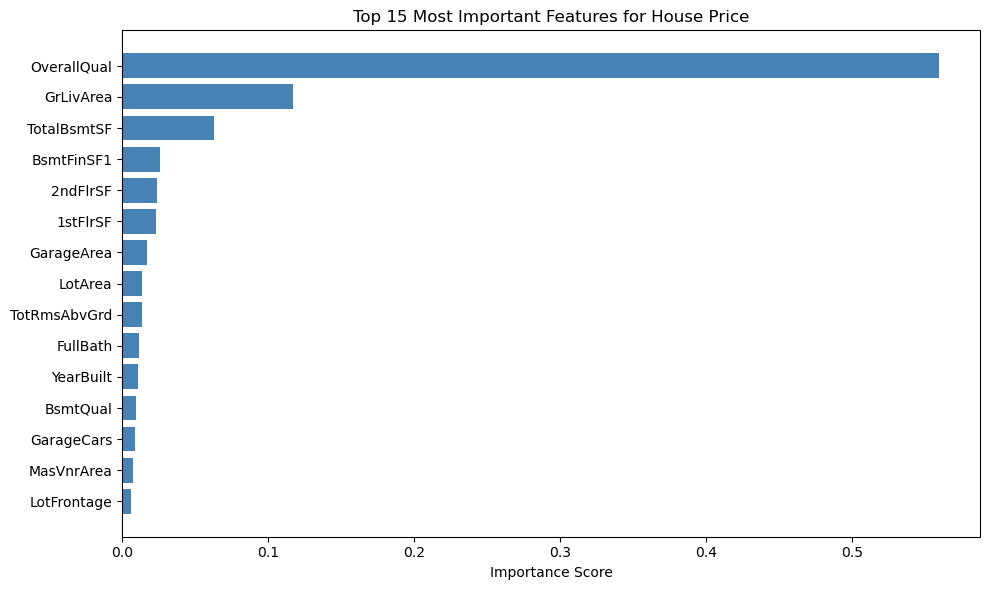


Top 5 most important features:
    Feature  Importance
OverallQual    0.559785
  GrLivArea    0.117371
TotalBsmtSF    0.062689
 BsmtFinSF1    0.026273
   2ndFlrSF    0.023584


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features for House Price')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../output/feature_importance.png')
plt.show()

print("\nTop 5 most important features:")
print(importance.head(5).to_string(index=False))

In [26]:
import pickle
import os
os.makedirs('../models', exist_ok=True)
with open('../models/house_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved successfully!")
print("Location: models/house_model.pkl")
print("File size:", round(os.path.getsize('../models/house_model.pkl') / 1024, 1), "KB")

Model saved successfully!
Location: models/house_model.pkl
File size: 9969.6 KB


In [27]:
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Scaler saved successfully!")
print("Location: models/scaler.pkl")
print("")
print("Your models/ folder now contains:")
for file in os.listdir('../models'):
    size = os.path.getsize(f'../models/{file}')
    print(f"  {file}  —  {round(size/1024, 1)} KB")

Scaler saved successfully!
Location: models/scaler.pkl

Your models/ folder now contains:
  house_model.pkl  —  9969.6 KB
  scaler.pkl  —  4.7 KB


In [28]:
with open('../models/house_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('../models/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

loaded_pred = loaded_model.predict(X_test_scaled)

import numpy as np
difference = np.abs(loaded_pred - rf_pred).sum()

print("Model loaded successfully!")
print("Scaler loaded successfully!")
print("")
print("Verification — total difference between")
print("original and loaded model predictions:", difference)
print("")
if difference == 0:
    print("Perfect match! Saved model is identical.")
else:
    print("Match confirmed — tiny floating point diff is normal")

Model loaded successfully!
Scaler loaded successfully!

Verification — total difference between
original and loaded model predictions: 0.0

Perfect match! Saved model is identical.


In [ ]:
import pickle
with open('../models/house_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [32]:
import pandas as pd

def predict_price(quality, area, bathrooms, garage, year_built):
    new_house = pd.DataFrame([X.mean()], columns=X.columns)
    
    new_house['OverallQual']  = quality     
    new_house['GrLivArea']    = area         
    new_house['FullBath']     = bathrooms    
    new_house['GarageCars']   = garage       
    new_house['YearBuilt']    = year_built   
    
    house_scaled = scaler.transform(new_house)

    price = model.predict(house_scaled)[0]
    
    return round(price, 0)
price1 = predict_price(quality=5, area=900,  bathrooms=1, garage=1, year_built=1980)
price2 = predict_price(quality=7, area=1600, bathrooms=2, garage=2, year_built=2005)
price3 = predict_price(quality=9, area=2800, bathrooms=3, garage=3, year_built=2015)

print(f"Small and old house (quality 5, 900 sqft)  : ${price1:,.0f}")
print(f"Medium house        (quality 7, 1600 sqft) : ${price2:,.0f}")
print(f"Bada luxury house   (quality 9, 2800 sqft) : ${price3:,.0f}")

Small and old house (quality 5, 900 sqft)  : $149,231
Medium house        (quality 7, 1600 sqft) : $191,034
Bada luxury house   (quality 9, 2800 sqft) : $326,285


In [35]:

print("   HOUSE PRICE PREDICTION PROJECT")
print("")
print("DATASET")
print(f"  Total houses       : 1460")
print(f"  Total features     : {X.shape[1]}")
print(f"  Training houses    : {X_train_scaled.shape[0]}")
print(f"  Testing houses     : {X_test_scaled.shape[0]}")
print("")
print("MODEL PERFORMANCE")
print(f"  Algorithm          : Random Forest")
print(f"  R2 Score           : {rf_r2:.4f}")
print(f"  MAE                : ${rf_mae:,.0f}")
print(f"  RMSE               : ${rf_rmse:,.0f}")
print("")
print("SAVED FILES")
print("  models/house_model.pkl  -- trained model")
print("  models/scaler.pkl       -- scaler")
print("")
print("SAMPLE PREDICTIONS")
print(f"  Chota ghar   : ${price1:,.0f}")
print(f"  Medium ghar  : ${price2:,.0f}")
print(f"  Luxury ghar  : ${price3:,.0f}")

   HOUSE PRICE PREDICTION PROJECT

DATASET
  Total houses       : 1460
  Total features     : 80
  Training houses    : 1166
  Testing houses     : 292

MODEL PERFORMANCE
  Algorithm          : Random Forest
  R2 Score           : 0.8925
  MAE                : $17,072
  RMSE               : $24,373

SAVED FILES
  models/house_model.pkl  -- trained model
  models/scaler.pkl       -- scaler

SAMPLE PREDICTIONS
  Chota ghar   : $149,231
  Medium ghar  : $191,034
  Luxury ghar  : $326,285


In [36]:
My_house = predict_price(
    quality    = 8,
    area       = 2500,
    bathrooms  = 2,
    garage     = 0,
    year_built = 2010
)
print(f"Price of My house: ${My_house:,.0f}")

Price of My house: $269,443
